In [3]:
from IPython.core.display import HTML

HTML("""
<style>

h1 { color: blue !important; }
h2 { color: green !important; }
</style>
""")

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
import seaborn as sns
import matplotlib.pyplot as plt 
from xgboost import XGBClassifier
# pip install xgboost ( enter this command in Anaconda Prompt)

# Step 1: Read and explore the data

In [2]:
data =  pd.read_csv("Hotel Reservations.csv")

In [3]:
data.head(100)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,INN00096,2,1,0,2,Meal Plan 1,1,Room_Type 1,134,2018,8,4,Online,0,0,0,130.50,2,Not_Canceled
96,INN00097,2,0,0,2,Meal Plan 2,0,Room_Type 1,320,2018,8,18,Online,0,0,0,115.00,1,Canceled
97,INN00098,2,0,0,4,Meal Plan 1,0,Room_Type 1,118,2018,4,13,Online,0,0,0,90.95,1,Not_Canceled
98,INN00099,2,0,0,3,Meal Plan 1,0,Room_Type 1,30,2018,11,17,Online,0,0,0,76.08,1,Not_Canceled


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [5]:
data.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [6]:
print(data['type_of_meal_plan'].value_counts())

Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: type_of_meal_plan, dtype: int64


In [7]:
print(data['room_type_reserved'].value_counts())

Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: room_type_reserved, dtype: int64


In [8]:
print(data['market_segment_type'].value_counts())

Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: market_segment_type, dtype: int64


In [9]:
print(data['booking_status'].value_counts())

Not_Canceled    24390
Canceled        11885
Name: booking_status, dtype: int64


In [10]:
print(data['required_car_parking_space'].value_counts())

0    35151
1     1124
Name: required_car_parking_space, dtype: int64


In [11]:
print(data['repeated_guest'].value_counts())

0    35345
1      930
Name: repeated_guest, dtype: int64


In [12]:
print(data['arrival_year'].value_counts())

2018    29761
2017     6514
Name: arrival_year, dtype: int64


In [13]:
print(data['arrival_month'].value_counts())

10    5317
9     4611
8     3813
6     3203
12    3021
11    2980
7     2920
4     2736
5     2598
3     2358
2     1704
1     1014
Name: arrival_month, dtype: int64


In [14]:
print(data['no_of_previous_bookings_not_canceled'].value_counts().head(10))
# As there are only ~3% repeat customers using previous booking data is not significant

0     35463
1       228
2       112
3        80
4        65
5        60
6        36
7        24
8        23
10       19
Name: no_of_previous_bookings_not_canceled, dtype: int64


In [15]:
print(data['no_of_special_requests'].value_counts().head(10))


0    19777
1    11373
2     4364
3      675
4       78
5        8
Name: no_of_special_requests, dtype: int64


In [16]:
print(data['no_of_adults'].value_counts())

2    26108
1     7695
3     2317
0      139
4       16
Name: no_of_adults, dtype: int64


In [17]:
print(data['no_of_children'].value_counts())
#Number of children 9 and 10 looks like outlier

0     33577
1      1618
2      1058
3        19
9         2
10        1
Name: no_of_children, dtype: int64


In [18]:
#oulier removal
data = data[data['no_of_children']<=3]
data.reset_index(inplace=True)

In [19]:
print(data.columns)

Index(['index', 'Booking_ID', 'no_of_adults', 'no_of_children',
       'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan',
       'required_car_parking_space', 'room_type_reserved', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'market_segment_type',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status'],
      dtype='object')


# Step 2: Create features

In [20]:
numerical_features = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time','repeated_guest',
       'avg_price_per_room', 'no_of_previous_bookings_not_canceled','no_of_special_requests']

In [21]:
categorical_features  = ['type_of_meal_plan','room_type_reserved','market_segment_type','arrival_month']


In [22]:
data = data[numerical_features + categorical_features + ['booking_status']  ]
data.head(10)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,avg_price_per_room,no_of_previous_bookings_not_canceled,no_of_special_requests,type_of_meal_plan,room_type_reserved,market_segment_type,arrival_month,booking_status
0,2,0,1,2,0,224,0,65.00,0,0,Meal Plan 1,Room_Type 1,Offline,10,Not_Canceled
1,2,0,2,3,0,5,0,106.68,0,1,Not Selected,Room_Type 1,Online,11,Not_Canceled
2,1,0,2,1,0,1,0,60.00,0,0,Meal Plan 1,Room_Type 1,Online,2,Canceled
3,2,0,0,2,0,211,0,100.00,0,0,Meal Plan 1,Room_Type 1,Online,5,Canceled
4,2,0,1,1,0,48,0,94.50,0,0,Not Selected,Room_Type 1,Online,4,Canceled
5,2,0,0,2,0,346,0,115.00,0,1,Meal Plan 2,Room_Type 1,Online,9,Canceled
6,2,0,1,3,0,34,0,107.55,0,1,Meal Plan 1,Room_Type 1,Online,10,Not_Canceled
7,2,0,1,3,0,83,0,105.61,0,1,Meal Plan 1,Room_Type 4,Online,12,Not_Canceled
8,3,0,0,4,0,121,0,96.90,0,1,Meal Plan 1,Room_Type 1,Offline,7,Not_Canceled
9,2,0,0,5,0,44,0,133.44,0,3,Meal Plan 1,Room_Type 4,Online,10,Not_Canceled


In [23]:
data = pd.get_dummies(data, columns =categorical_features, drop_first= False) # dtype = int
data['booking_status'] = data['booking_status'].map({'Not_Canceled':0, 'Canceled' : 1})

# Step 3: Train test split the data

In [24]:
def train_test_split_and_features(data):
    y = data['booking_status']
    x = data.drop('booking_status',axis=1)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, shuffle = False, random_state = 0)
    print(x.head(5))
    print(x.columns)
    features = list(x.columns)
    return x_train, x_test, y_train, y_test,features


In [25]:
x_train, x_test, y_train, y_test,features = train_test_split_and_features(data)

   no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
0             2               0                     1                  2   
1             2               0                     2                  3   
2             1               0                     2                  1   
3             2               0                     0                  2   
4             2               0                     1                  1   

   required_car_parking_space  lead_time  repeated_guest  avg_price_per_room  \
0                           0        224               0               65.00   
1                           0          5               0              106.68   
2                           0          1               0               60.00   
3                           0        211               0              100.00   
4                           0         48               0               94.50   

   no_of_previous_bookings_not_canceled  no_of_special_request

In [26]:
x_train.head(10)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,avg_price_per_room,no_of_previous_bookings_not_canceled,no_of_special_requests,...,arrival_month_3,arrival_month_4,arrival_month_5,arrival_month_6,arrival_month_7,arrival_month_8,arrival_month_9,arrival_month_10,arrival_month_11,arrival_month_12
0,2,0,1,2,0,224,0,65.00,0,0,...,0,0,0,0,0,0,0,1,0,0
1,2,0,2,3,0,5,0,106.68,0,1,...,0,0,0,0,0,0,0,0,1,0
2,1,0,2,1,0,1,0,60.00,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2,0,0,2,0,211,0,100.00,0,0,...,0,0,1,0,0,0,0,0,0,0
4,2,0,1,1,0,48,0,94.50,0,0,...,0,1,0,0,0,0,0,0,0,0
5,2,0,0,2,0,346,0,115.00,0,1,...,0,0,0,0,0,0,1,0,0,0
6,2,0,1,3,0,34,0,107.55,0,1,...,0,0,0,0,0,0,0,1,0,0
7,2,0,1,3,0,83,0,105.61,0,1,...,0,0,0,0,0,0,0,0,0,1
8,3,0,0,4,0,121,0,96.90,0,1,...,0,0,0,0,1,0,0,0,0,0
9,2,0,0,5,0,44,0,133.44,0,3,...,0,0,0,0,0,0,0,1,0,0


In [27]:
help(XGBClassifier)
#https://xgboost.readthedocs.io/en/stable/parameter.html

Help on class XGBClassifier in module xgboost.sklearn:

class XGBClassifier(XGBModel, sklearn.base.ClassifierMixin)
 |  XGBClassifier(*, objective: Union[str, Callable[[numpy.ndarray, numpy.ndarray], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'binary:logistic', use_label_encoder: Optional[bool] = None, **kwargs: Any) -> None
 |  
 |  Implementation of the scikit-learn API for XGBoost classification.
 |  
 |  
 |  Parameters
 |  ----------
 |  
 |      n_estimators : int
 |          Number of boosting rounds.
 |  
 |      max_depth :  Optional[int]
 |          Maximum tree depth for base learners.
 |      max_leaves :
 |          Maximum number of leaves; 0 indicates no limit.
 |      max_bin :
 |          If using histogram-based algorithm, maximum number of bins per feature
 |      grow_policy :
 |          Tree growing policy. 0: favor splitting at nodes closest to the node, i.e. grow
 |          depth-wise. 1: favor splitting at nodes with highest loss change.
 |      learnin

# Step 4: Fit and evaluate the model

In [28]:
def fit_and_evaluate_model(x_train, x_test, y_train, y_test,xgb):
    xgb.fit(x_train, y_train)
    xgb_predict = xgb.predict(x_test)
    xgb_conf_matrix = confusion_matrix(y_test, xgb_predict)
    xgb_acc_score = accuracy_score(y_test, xgb_predict)
    print("confussion matrix")
    print(xgb_conf_matrix)
    print("\n")
    print("Accuracy of XGBoost:",xgb_acc_score*100,'\n')
    print(classification_report(y_test,xgb_predict))
    return xgb

In [46]:
#Default parameters:
   # learning_rate = 0.3 # shrinkage factor
   # max_depth = 6 # maximum depth of decision tree ( weak learner)
   # subsample = 1 # percetage of the data used for training every weak learner / DT
   # colsample_bytree = 1 # percetage of the features used for training every weak learner / DT
   # n_estimators = 100 # number of weak learners
xgb =  XGBClassifier()
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test,xgb)

confussion matrix
[[4576  278]
 [ 543 1858]]


Accuracy of XGBoost: 88.68366643694004 

              precision    recall  f1-score   support

           0       0.89      0.94      0.92      4854
           1       0.87      0.77      0.82      2401

    accuracy                           0.89      7255
   macro avg       0.88      0.86      0.87      7255
weighted avg       0.89      0.89      0.89      7255



In [47]:
importances = pd.DataFrame(model.feature_importances_) # calculated gain
importances['features'] = features
importances.columns = ['importance','feature']
importances.sort_values(by = 'importance', ascending= True,inplace=True)

<BarContainer object of 38 artists>

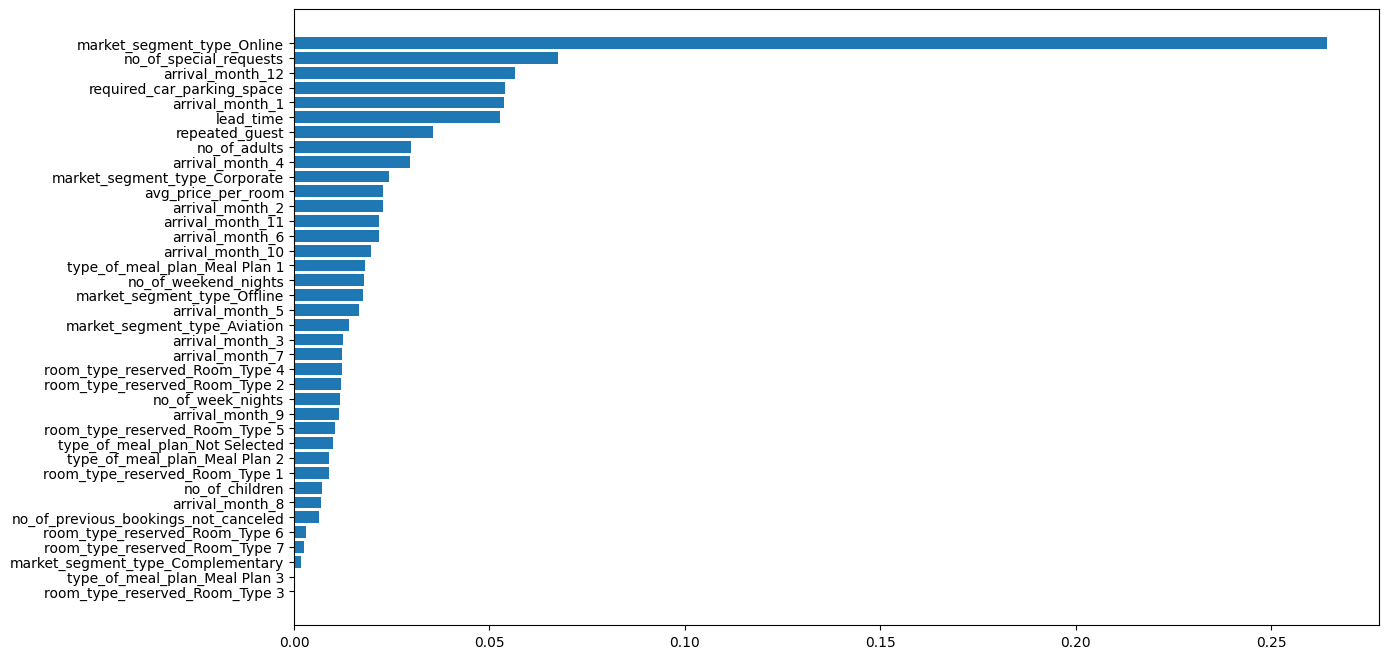

In [50]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 8))
plt.barh(importances.feature, importances.importance)

# Step 5: Hyperparameter optimization

In [30]:
#Default parameters:
   # learning_rate = 0.3
   # max_depth = 6
   # subsample = 1
   # colsample_bytree = 1
   # n_estimators = 100

param_grid = [{'learning_rate': [0.1, 0.3, 0.5, 0.7],
               'max_depth': [3,6,10],
               'subsample': [0.8, 1],
               'colsample_bytree': [0.8, 1],
               'n_estimators' : [50, 100, 150]}
             ]


In [31]:
from sklearn.model_selection import GridSearchCV
model = XGBClassifier(random_state=0)
search = GridSearchCV(estimator = model, param_grid = param_grid, cv=5, refit=True, verbose=5)
search.fit(x_train, y_train)


Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.8;, score=0.855 total time=   0.2s
[CV 2/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.8;, score=0.850 total time=   0.2s
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.8;, score=0.829 total time=   0.2s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.8;, score=0.837 total time=   0.2s
[CV 5/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.8;, score=0.833 total time=   0.2s
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=1;, score=0.860 total time=   0.2s
[CV 2/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=3, n_estimators=50, subsample=1;, score=0.842 total time=   0.1s
[CV 3/5] END colsample_b

[CV 4/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=10, n_estimators=50, subsample=0.8;, score=0.888 total time=   0.9s
[CV 5/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=10, n_estimators=50, subsample=0.8;, score=0.889 total time=   0.9s
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=10, n_estimators=50, subsample=1;, score=0.890 total time=   0.8s
[CV 2/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=10, n_estimators=50, subsample=1;, score=0.888 total time=   0.8s
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=10, n_estimators=50, subsample=1;, score=0.881 total time=   0.8s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=10, n_estimators=50, subsample=1;, score=0.888 total time=   0.8s
[CV 5/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=10, n_estimators=50, subsample=1;, score=0.887 total time=   0.8s
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.1, max_depth=10, n_estimators=100, 

[CV 2/5] END colsample_bytree=0.8, learning_rate=0.3, max_depth=6, n_estimators=50, subsample=1;, score=0.884 total time=   0.4s
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.3, max_depth=6, n_estimators=50, subsample=1;, score=0.877 total time=   0.4s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.3, max_depth=6, n_estimators=50, subsample=1;, score=0.884 total time=   0.4s
[CV 5/5] END colsample_bytree=0.8, learning_rate=0.3, max_depth=6, n_estimators=50, subsample=1;, score=0.883 total time=   0.4s
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.3, max_depth=6, n_estimators=100, subsample=0.8;, score=0.895 total time=   1.0s
[CV 2/5] END colsample_bytree=0.8, learning_rate=0.3, max_depth=6, n_estimators=100, subsample=0.8;, score=0.891 total time=   1.0s
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.3, max_depth=6, n_estimators=100, subsample=0.8;, score=0.882 total time=   1.0s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.3, max_depth=6, n_estimators=100, sub

[CV 5/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=3, n_estimators=50, subsample=1;, score=0.861 total time=   0.2s
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=3, n_estimators=100, subsample=0.8;, score=0.884 total time=   0.6s
[CV 2/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=3, n_estimators=100, subsample=0.8;, score=0.880 total time=   0.6s
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=3, n_estimators=100, subsample=0.8;, score=0.867 total time=   0.7s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=3, n_estimators=100, subsample=0.8;, score=0.874 total time=   0.8s
[CV 5/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=3, n_estimators=100, subsample=0.8;, score=0.868 total time=   0.7s
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=3, n_estimators=100, subsample=1;, score=0.883 total time=   0.6s
[CV 2/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=3, n_estimators=1

[CV 3/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=10, n_estimators=100, subsample=0.8;, score=0.885 total time=   1.7s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=10, n_estimators=100, subsample=0.8;, score=0.888 total time=   1.7s
[CV 5/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=10, n_estimators=100, subsample=0.8;, score=0.894 total time=   1.7s
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=10, n_estimators=100, subsample=1;, score=0.895 total time=   1.4s
[CV 2/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=10, n_estimators=100, subsample=1;, score=0.887 total time=   1.5s
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=10, n_estimators=100, subsample=1;, score=0.890 total time=   1.5s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=10, n_estimators=100, subsample=1;, score=0.889 total time=   1.4s
[CV 5/5] END colsample_bytree=0.8, learning_rate=0.5, max_depth=10, n_estimat

...

[CV 2/5] END colsample_bytree=1, learning_rate=0.3, max_depth=6, n_estimators=150, subsample=1;, score=0.894 total time=   1.5s
[CV 3/5] END colsample_bytree=1, learning_rate=0.3, max_depth=6, n_estimators=150, subsample=1;, score=0.882 total time=   1.5s
[CV 4/5] END colsample_bytree=1, learning_rate=0.3, max_depth=6, n_estimators=150, subsample=1;, score=0.886 total time=   1.5s
[CV 5/5] END colsample_bytree=1, learning_rate=0.3, max_depth=6, n_estimators=150, subsample=1;, score=0.895 total time=   1.5s
[CV 1/5] END colsample_bytree=1, learning_rate=0.3, max_depth=10, n_estimators=50, subsample=0.8;, score=0.894 total time=   1.0s
[CV 2/5] END colsample_bytree=1, learning_rate=0.3, max_depth=10, n_estimators=50, subsample=0.8;, score=0.889 total time=   1.0s
[CV 3/5] END colsample_bytree=1, learning_rate=0.3, max_depth=10, n_estimators=50, subsample=0.8;, score=0.882 total time=   1.0s
[CV 4/5] END colsample_bytree=1, learning_rate=0.3, max_depth=10, n_estimators=50, subsample=0.8;,

[CV 1/5] END colsample_bytree=1, learning_rate=0.5, max_depth=6, n_estimators=50, subsample=0.8;, score=0.892 total time=   0.6s
[CV 2/5] END colsample_bytree=1, learning_rate=0.5, max_depth=6, n_estimators=50, subsample=0.8;, score=0.885 total time=   0.6s
[CV 3/5] END colsample_bytree=1, learning_rate=0.5, max_depth=6, n_estimators=50, subsample=0.8;, score=0.882 total time=   0.6s
[CV 4/5] END colsample_bytree=1, learning_rate=0.5, max_depth=6, n_estimators=50, subsample=0.8;, score=0.882 total time=   0.6s
[CV 5/5] END colsample_bytree=1, learning_rate=0.5, max_depth=6, n_estimators=50, subsample=0.8;, score=0.883 total time=   0.6s
[CV 1/5] END colsample_bytree=1, learning_rate=0.5, max_depth=6, n_estimators=50, subsample=1;, score=0.890 total time=   0.5s
[CV 2/5] END colsample_bytree=1, learning_rate=0.5, max_depth=6, n_estimators=50, subsample=1;, score=0.886 total time=   0.5s
[CV 3/5] END colsample_bytree=1, learning_rate=0.5, max_depth=6, n_estimators=50, subsample=1;, score

[CV 5/5] END colsample_bytree=1, learning_rate=0.7, max_depth=3, n_estimators=50, subsample=0.8;, score=0.863 total time=   0.3s
[CV 1/5] END colsample_bytree=1, learning_rate=0.7, max_depth=3, n_estimators=50, subsample=1;, score=0.880 total time=   0.3s
[CV 2/5] END colsample_bytree=1, learning_rate=0.7, max_depth=3, n_estimators=50, subsample=1;, score=0.873 total time=   0.2s
[CV 3/5] END colsample_bytree=1, learning_rate=0.7, max_depth=3, n_estimators=50, subsample=1;, score=0.864 total time=   0.3s
[CV 4/5] END colsample_bytree=1, learning_rate=0.7, max_depth=3, n_estimators=50, subsample=1;, score=0.864 total time=   0.2s
[CV 5/5] END colsample_bytree=1, learning_rate=0.7, max_depth=3, n_estimators=50, subsample=1;, score=0.864 total time=   0.3s
[CV 1/5] END colsample_bytree=1, learning_rate=0.7, max_depth=3, n_estimators=100, subsample=0.8;, score=0.883 total time=   0.7s
[CV 2/5] END colsample_bytree=1, learning_rate=0.7, max_depth=3, n_estimators=100, subsample=0.8;, score=0

[CV 4/5] END colsample_bytree=1, learning_rate=0.7, max_depth=10, n_estimators=50, subsample=1;, score=0.882 total time=   0.8s
[CV 5/5] END colsample_bytree=1, learning_rate=0.7, max_depth=10, n_estimators=50, subsample=1;, score=0.895 total time=   0.9s
[CV 1/5] END colsample_bytree=1, learning_rate=0.7, max_depth=10, n_estimators=100, subsample=0.8;, score=0.895 total time=   2.0s
[CV 2/5] END colsample_bytree=1, learning_rate=0.7, max_depth=10, n_estimators=100, subsample=0.8;, score=0.885 total time=   2.0s
[CV 3/5] END colsample_bytree=1, learning_rate=0.7, max_depth=10, n_estimators=100, subsample=0.8;, score=0.879 total time=   2.0s
[CV 4/5] END colsample_bytree=1, learning_rate=0.7, max_depth=10, n_estimators=100, subsample=0.8;, score=0.880 total time=   2.0s
[CV 5/5] END colsample_bytree=1, learning_rate=0.7, max_depth=10, n_estimators=100, subsample=0.8;, score=0.890 total time=   2.0s
[CV 1/5] END colsample_bytree=1, learning_rate=0.7, max_depth=10, n_estimators=100, subsa

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, n_jobs=None,
                                     num_parallel_tree=None, predictor=None,
                                     random_state=0, ...),
             param_grid=[{'colsample_bytree': [0.8, 1],
                          'learning_rate': [0.1, 0.3, 0.5, 0.7],
                          'max_depth': [3, 6, 10],
                          'n_estimators': [50, 100, 150],
                          'subsample': [0.8, 1]}],
             verbose=5)

In [32]:
results = pd.DataFrame(search.cv_results_)
results.sort_values('mean_test_score',inplace=True,ascending= False)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
88,3.409931,0.202068,0.016095,0.000395,1,0.1,10,150,0.8,"{'colsample_bytree': 1, 'learning_rate': 0.1, ...",0.899035,0.895762,0.885921,0.891952,0.899707,0.894475,0.005086,1
16,2.554485,0.014042,0.015625,0.000004,0.8,0.1,10,150,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.898691,0.894900,0.889195,0.890229,0.895399,0.893683,0.003509,2
17,2.266194,0.013538,0.015624,0.000003,0.8,0.1,10,150,1,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.895417,0.895245,0.885921,0.891780,0.896261,0.892925,0.003823,3
33,1.706777,0.144841,0.016460,0.002370,0.8,0.3,10,100,1,"{'colsample_bytree': 0.8, 'learning_rate': 0.3...",0.895762,0.892316,0.890402,0.889368,0.894020,0.892373,0.002329,4
107,2.851090,0.062689,0.015626,0.000002,1,0.3,10,150,1,"{'colsample_bytree': 1, 'learning_rate': 0.3, ...",0.898518,0.891282,0.891952,0.887300,0.892469,0.892304,0.003602,5
14,1.783026,0.021363,0.011775,0.006052,0.8,0.1,10,100,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.896968,0.893522,0.886438,0.890402,0.894020,0.892270,0.003583,6
35,3.219894,0.316522,0.022640,0.007297,0.8,0.3,10,150,1,"{'colsample_bytree': 0.8, 'learning_rate': 0.3...",0.895072,0.891454,0.888161,0.888506,0.895744,0.891787,0.003177,7
32,1.778033,0.006645,0.005545,0.006882,0.8,0.3,10,100,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.3...",0.903170,0.892143,0.883164,0.885749,0.894710,0.891787,0.007058,8
86,2.255161,0.065522,0.017072,0.002897,1,0.1,10,100,0.8,"{'colsample_bytree': 1, 'learning_rate': 0.1, ...",0.895245,0.894728,0.882475,0.890574,0.894882,0.891581,0.004861,9
34,3.234967,0.047685,0.022742,0.006090,0.8,0.3,10,150,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.3...",0.899207,0.893177,0.885232,0.885576,0.894020,0.891443,0.005347,10


In [33]:
results_save = pd.DataFrame(search.cv_results_)
results_save.to_csv("results_xgb_cv_save_new.csv", index =False)

In [34]:
search.best_params_

{'colsample_bytree': 1,
 'learning_rate': 0.1,
 'max_depth': 10,
 'n_estimators': 150,
 'subsample': 0.8}

In [35]:
xgb = search.best_estimator_
# this is just to show the possibility
# but it is recommended to train the model on complete training dataset again
xgb_predict = xgb.predict(x_test)
xgb_conf_matrix = confusion_matrix(y_test, xgb_predict)
xgb_acc_score = accuracy_score(y_test, xgb_predict)
print("confussion matrix")
print(xgb_conf_matrix)
print("\n")
print("Accuracy of XGBoost:",xgb_acc_score*100,'\n')
print(classification_report(y_test,xgb_predict))

confussion matrix
[[4584  270]
 [ 514 1887]]


Accuracy of XGBoost: 89.19365954514127 

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4854
           1       0.87      0.79      0.83      2401

    accuracy                           0.89      7255
   macro avg       0.89      0.87      0.87      7255
weighted avg       0.89      0.89      0.89      7255



In [36]:
# try to fit the model with best parameters on complete training data
# evaluate the model on test data - to check if it gives better performance

# Step 6: Precison Recall analysis

In [37]:
from sklearn.metrics import precision_recall_curve
xgb_predict = xgb.predict(x_test)
xgb_proba = xgb.predict_proba(x_test)
print(xgb_proba[0:10])
print(xgb_predict)

[[0.00788081 0.9921192 ]
 [0.88783914 0.11216084]
 [0.9946456  0.00535439]
 [0.00716782 0.9928322 ]
 [0.9202157  0.07978427]
 [0.92617077 0.07382924]
 [0.33229733 0.6677027 ]
 [0.93199027 0.0680097 ]
 [0.2771806  0.7228194 ]
 [0.99828726 0.00171276]]
[1 0 0 ... 0 1 0]


In [38]:
help( xgb.predict)

Help on method predict in module xgboost.sklearn:

predict(X: Any, output_margin: bool = False, ntree_limit: Optional[int] = None, validate_features: bool = True, base_margin: Optional[Any] = None, iteration_range: Optional[Tuple[int, int]] = None) -> numpy.ndarray method of xgboost.sklearn.XGBClassifier instance
    Predict with `X`.  If the model is trained with early stopping, then `best_iteration`
    is used automatically.  For tree models, when data is on GPU, like cupy array or
    cuDF dataframe and `predictor` is not specified, the prediction is run on GPU
    automatically, otherwise it will run on CPU.
    
    .. note:: This function is only thread safe for `gbtree` and `dart`.
    
    Parameters
    ----------
    X :
        Data to predict with.
    output_margin :
        Whether to output the raw untransformed margin value.
    ntree_limit :
        Deprecated, use `iteration_range` instead.
    validate_features :
        When this is True, validate that the Booster'

In [39]:
precision, recall, thresholds = precision_recall_curve(y_test, xgb_proba[:,1])

In [40]:
#Precision = TP / (TP + FP)
#Precision indicates the proportion of positive predictions that were actually correct.

# for something like cancer prediciton -
# not cancer - class 0
# cancer - class 1
# default threshold: 0.5 
# 0.4 - cancer - increase the chance of catching cancer cases - increae chance of false postives

#Recall = TP / (TP + FN)
#Recall indicates the proportion of actual positive instances that were correctly identified by the model.

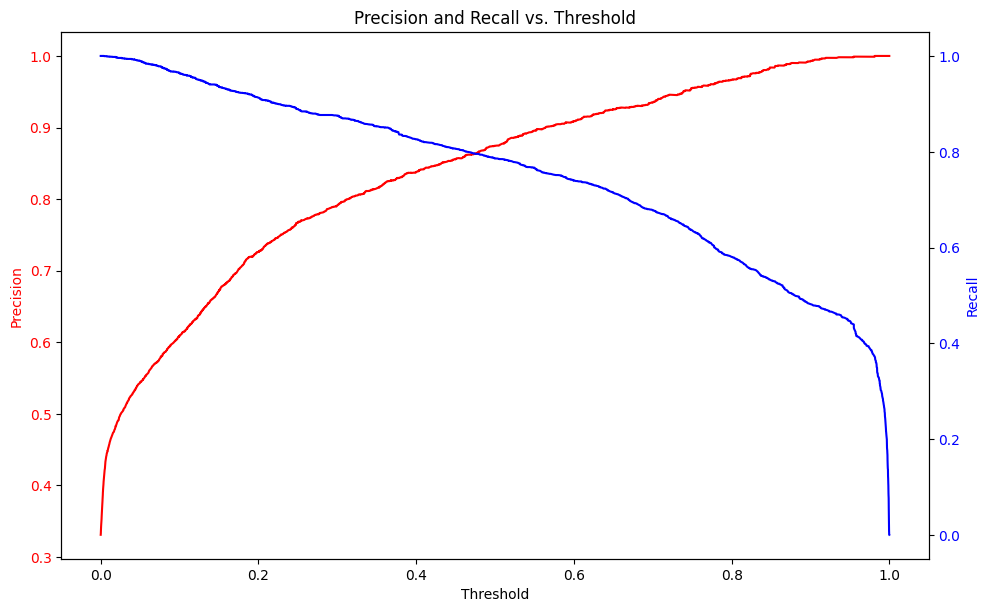

In [41]:
import numpy as np
# Plot precision and recall on separate y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Threshold')
ax1.set_ylabel('Precision', color='red')
ax1.plot(thresholds, precision[:-1], color='red', label='Precision')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.set_ylabel('Recall', color='blue')
ax2.plot(thresholds, recall[:-1], color='blue', label='Recall')
ax2.tick_params(axis='y', labelcolor='blue')


fig.tight_layout()
plt.title('Precision and Recall vs. Threshold')
plt.show()


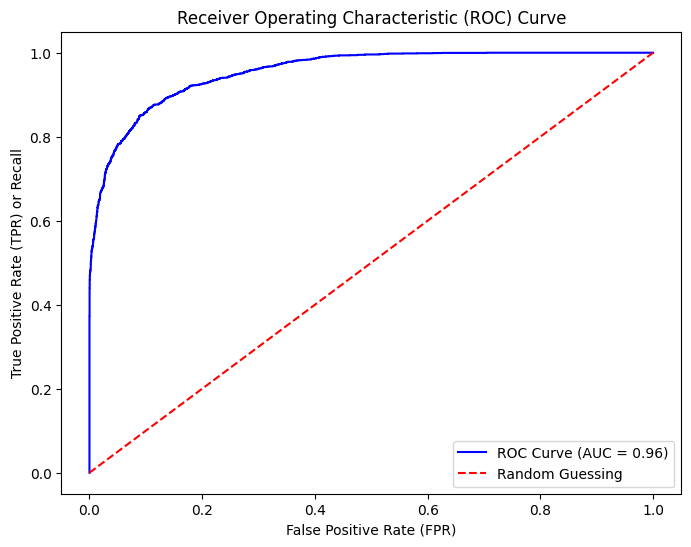

In [42]:
# applicable for any binary classfication model 

#FPR = FP / (FP + TN)
#It measures the proportion of actual negative instances that are incorrectly predicted as positive.

#TPR = TP / (TP + FN)
#It measures the proportion of actual positive instances that are correctly predicted as positive.

from sklearn.metrics import roc_curve, auc


# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, xgb_proba[:,1])

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) or Recall')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Step 7: Trying different threshold value for classification

In [43]:
# Default results

xgb_conf_matrix = confusion_matrix(y_test, xgb_predict)
xgb_acc_score = accuracy_score(y_test, xgb_predict)
print("confussion matrix")
print(xgb_conf_matrix)
print("\n")
print("Accuracy of XGBoost:",xgb_acc_score*100,'\n')
print(classification_report(y_test,xgb_predict))

confussion matrix
[[4584  270]
 [ 514 1887]]


Accuracy of XGBoost: 89.19365954514127 

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4854
           1       0.87      0.79      0.83      2401

    accuracy                           0.89      7255
   macro avg       0.89      0.87      0.87      7255
weighted avg       0.89      0.89      0.89      7255



In [44]:

# Results with new threshold

custom_threshold = 0.35

# Apply the custom threshold to obtain binary predictions
custom_predictions = (xgb_proba[:,1] > custom_threshold).astype(int)
print(xgb_proba[:,1])
print(custom_predictions)


[0.9921192  0.11216084 0.00535439 ... 0.07443101 0.6094807  0.00366058]
[1 0 0 ... 0 1 0]


In [45]:
#Precision = TP / (TP + FP)
#Precision indicates the proportion of positive predictions that were actually correct.

#Recall = TP / (TP + FN)
#Recall indicates the proportion of actual positive instances that were correctly identified by the model.

xgb_conf_matrix = confusion_matrix(y_test, custom_predictions)
xgb_acc_score = accuracy_score(y_test, custom_predictions)
print("confussion matrix")
print(xgb_conf_matrix)
print("\n")
print("Accuracy of XGBoost:",xgb_acc_score*100,'\n')
print(classification_report(y_test,custom_predictions))

confussion matrix
[[4389  465]
 [ 353 2048]]


Accuracy of XGBoost: 88.7250172294969 

              precision    recall  f1-score   support

           0       0.93      0.90      0.91      4854
           1       0.81      0.85      0.83      2401

    accuracy                           0.89      7255
   macro avg       0.87      0.88      0.87      7255
weighted avg       0.89      0.89      0.89      7255

